# 8. k-srednjih vrednosti (k-Means)

## Nadgledano vs. nenadgledano učenje

| | nadgledano | nenadgledano |
|---|---|---|
| podaci | $(x^{(1)}, y^{(1)}), \dots, (x^{(m)}, y^{(m)})$ | $x^{(1)}, x^{(2)}, \dots, x^{(m)}$ |
| oznake | **postoje** | **ne postoje** |
| cilj | naučiti preslikavanje $x \to y$, naći granicu odlučivanja | pronaći **strukturu** u podacima |

Kod nenadgledanog učenja ne znamo „tačne odgovore" — algoritam sam pokušava da otkrije
kako su podaci organizovani.

## Gde se koristi klasterovanje

1. **Segmentacija tržišta** — podela korisnika u grupe kupaca; omogućava ciljani marketing i prilagođene ponude
2. **Analiza društvenih mreža** — otkrivanje koherentnih grupa ljudi, zajednica prijatelja ili saradnika
3. **Organizacija računarskih sistema i data centara** — klasterovanje računara koji često rade zajedno i intenzivno razmenjuju podatke

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.datasets import make_blobs, make_moons, load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, adjusted_rand_score

plt.rcParams["figure.figsize"] = (9, 4.5); plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True; plt.rcParams["grid.alpha"] = 0.3
RS = 42

X, y_pravo = make_blobs(n_samples=300, centers=4, cluster_std=1.1, random_state=RS)
print(f"Podaci: {X.shape[0]} tacaka u {X.shape[1]}D — BEZ oznaka")

Podaci: 300 tacaka u 2D — BEZ oznaka


## Algoritam

**Ulaz:** broj klastera $K$ (biramo ga mi) i neoznačen skup $x^{(1)}, \dots, x^{(m)}$,
gde je $x^{(i)} \in \mathbb{R}^n$.

**1. Inicijalizacija**
Nasumično izabrati $K$ centroida $\mu_1, \dots, \mu_K \in \mathbb{R}^n$ (obično $K$
nasumičnih trening tačaka).

**2. Ponavljati do konvergencije:**

**(a) Korak dodele klastera** — za svaki primer $x^{(i)}$:
$$c^{(i)} := \arg\min_{k} \lVert x^{(i)} - \mu_k \rVert^2$$
Svaka tačka se dodeljuje **najbližem centroidu**.

**(b) Korak pomeranja centroida** — za svaki klaster $k$:
$$\mu_k := \frac{1}{|\{i : c^{(i)} = k\}|} \sum_{i : c^{(i)} = k} x^{(i)}$$
Centroid se pomera u **aritmetičku sredinu** svojih tačaka.

**Zaustavljanje:** kada se centroidi više ne pomeraju **ili** kada se dodele klastera više
ne menjaju.

> Ako neki klaster ostane bez ijedne tačke, najčešće se eliminiše ili se centroid ponovo
> nasumično inicijalizuje.

In [2]:
def kmeans_rucno(X, K, max_iter=10, seed=3):
    'Rucna implementacija — da se vidi sta algoritam radi u svakoj iteraciji.'
    r = np.random.RandomState(seed)
    mu = X[r.choice(len(X), K, replace=False)].copy()     # 1. inicijalizacija
    istorija = []
    for it in range(max_iter):
        # (a) dodela: svaka tacka najblizem centroidu
        d = np.linalg.norm(X[:, None, :] - mu[None, :, :], axis=2)
        c = d.argmin(axis=1)
        # funkcija cilja J
        J = np.mean(np.sum((X - mu[c]) ** 2, axis=1))
        istorija.append((mu.copy(), c.copy(), J))
        # (b) pomeranje: centroid = prosek svojih tacaka
        novi = np.array([X[c == k].mean(axis=0) if (c == k).any() else mu[k] for k in range(K)])
        if np.allclose(novi, mu):
            break
        mu = novi
    return istorija

ist = kmeans_rucno(X, K=4)
print(f"Konvergiralo posle {len(ist)} iteracija\n")
print(f"{'iteracija':>10} {'J (funkcija cilja)':>20}")
for i, (_, _, J) in enumerate(ist):
    print(f"{i:>10} {J:>20.4f}")
print("\n-> J NIKADA ne raste. To je garancija konvergencije.")

Konvergiralo posle 5 iteracija

 iteracija   J (funkcija cilja)
         0              53.2335
         1               9.6813
         2               7.2049
         3               7.2043
         4               7.2041

-> J NIKADA ne raste. To je garancija konvergencije.


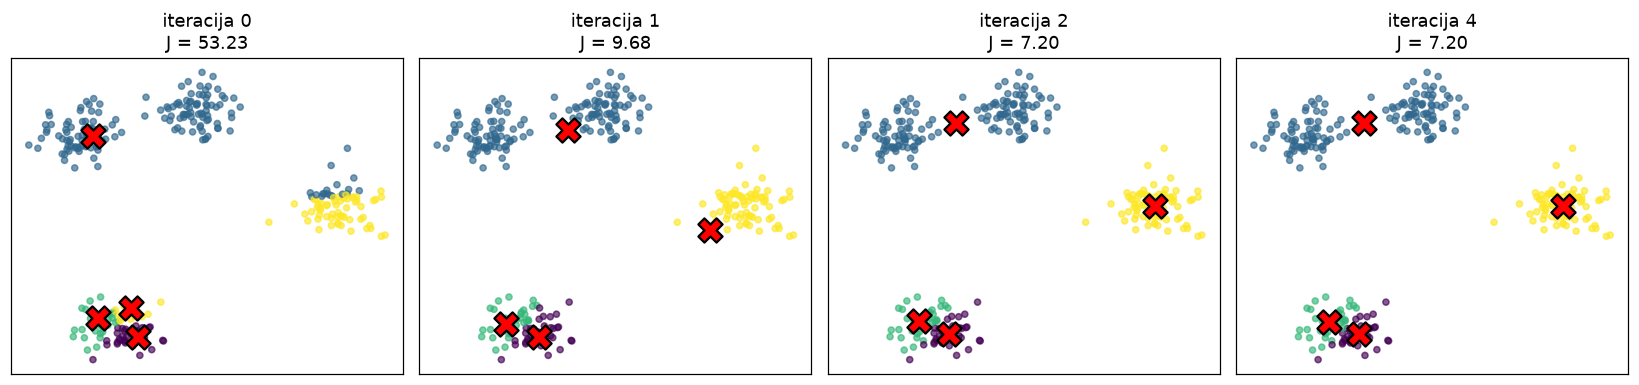

Crveni X su centroidi. Vidi se kako se pomeraju ka centrima svojih grupa.


In [3]:
prikaz = [0, 1, 2, len(ist) - 1]
fig, ax = plt.subplots(1, 4, figsize=(15, 3.6))
for a, i in zip(ax, prikaz):
    mu, c, J = ist[i]
    a.scatter(X[:, 0], X[:, 1], c=c, s=16, cmap="viridis", alpha=0.65)
    a.scatter(mu[:, 0], mu[:, 1], c="red", s=250, marker="X", edgecolor="k", linewidth=1.5)
    a.set_title(f"iteracija {i}\nJ = {J:.2f}"); a.set_xticks([]); a.set_yticks([])
plt.tight_layout(); plt.show()
print("Crveni X su centroidi. Vidi se kako se pomeraju ka centrima svojih grupa.")

## Optimizacioni cilj

Kao i algoritmi nadgledanog učenja, k-means ima **funkciju cilja** koju minimizuje:

$$J(c^{(1)},\dots,c^{(m)}, \mu_1,\dots,\mu_K) = \frac{1}{m}\sum_{i=1}^{m}\big\lVert x^{(i)} - \mu_{c^{(i)}} \big\rVert^2$$

To je **prosečno kvadratno rastojanje** tačaka od centroida svog klastera. Manje $J$ znači
kompaktnije klastere.

### Zašto $J$ nikada ne raste

k-means radi **naizmeničnu optimizaciju**:

| korak | šta je fiksno | šta se minimizuje |
|---|---|---|
| **(a) dodela** | centroidi $\mu$ | bira se $c^{(i)}$ koje minimizuje $J$ |
| **(b) pomeranje** | dodele $c$ | biraju se $\mu_k$ koji minimizuju $J$ |

Oba koraka smanjuju (ili ostavljaju istim) $J$, pa algoritam uvek **konvergira** — ali u
**lokalni** minimum.

**Provera ispravnosti:** ako $J$ raste ili osciluje kroz iteracije, nešto nije u redu
sa implementacijom.

## Lokalni optimum i višestruka inicijalizacija

k-means **ne garantuje globalni optimum** — rezultat zavisi od nasumične inicijalizacije.

**Loša rešenja** se prepoznaju po tome što jedan klaster „proguta" previše tačaka, dok
neki imaju vrlo malo ili samo jednu tačku. Distorzija $J$ je veća, a algoritam više ne
može da se popravi.

**Rešenje:** pokrenuti k-means više puta (npr. 50–1000), svaki put sa drugom nasumičnom
inicijalizacijom, izračunati $J$, i izabrati klasterizaciju sa **najmanjom** vrednošću.

U `scikit-learn` to radi parametar **`n_init`**.

In [4]:
Xl, _ = make_blobs(n_samples=300, centers=5, cluster_std=1.3, random_state=7)

print(f"{'seed':>6} {'J (inertia)':>14}")
J_vrednosti = []
for s in range(8):
    km = KMeans(n_clusters=5, n_init=1, init="random", random_state=s).fit(Xl)
    J_vrednosti.append(km.inertia_)
    print(f"{s:>6} {km.inertia_:>14.2f}")

print(f"\nRazlika najbolje-najgore: {max(J_vrednosti)-min(J_vrednosti):.2f}")
kmb = KMeans(n_clusters=5, n_init=50, random_state=RS).fit(Xl)
print(f"Sa n_init=50 (bira najbolje od 50): J = {kmb.inertia_:.2f}")

  seed    J (inertia)


     0        1811.90
     1         967.02
     2        3373.79
     3         967.02
     4        1811.90
     5        3324.89
     6         967.02
     7         967.02

Razlika najbolje-najgore: 2406.76
Sa n_init=50 (bira najbolje od 50): J = 967.02


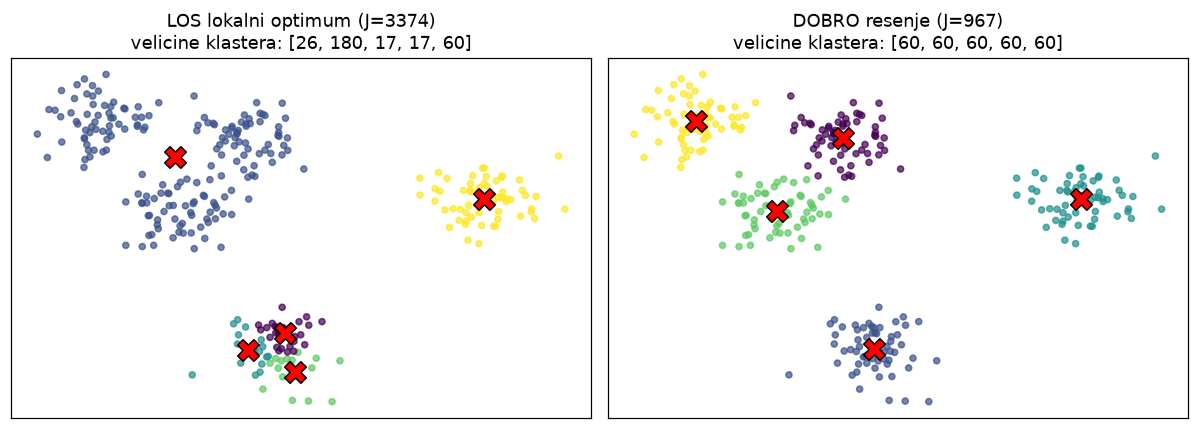

In [5]:
najgori = int(np.argmax(J_vrednosti))
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for a, (km, naslov) in zip(ax, [
        (KMeans(n_clusters=5, n_init=1, init="random", random_state=najgori).fit(Xl),
         f"LOS lokalni optimum (J={max(J_vrednosti):.0f})"),
        (kmb, f"DOBRO resenje (J={kmb.inertia_:.0f})")]):
    a.scatter(Xl[:, 0], Xl[:, 1], c=km.labels_, s=16, cmap="viridis", alpha=0.7)
    a.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
              c="red", s=200, marker="X", edgecolor="k")
    velicine = np.bincount(km.labels_, minlength=5)
    a.set_title(f"{naslov}\nvelicine klastera: {velicine.tolist()}")
    a.set_xticks([]); a.set_yticks([])
plt.tight_layout(); plt.show()

## Kako izabrati broj klastera $K$

U nenadgledanom učenju **nema tačnog odgovora** — broj klastera je često subjektivan.
Isti podaci nekome izgledaju kao 2, nekome kao 3 ili 4 grupe, i sve interpretacije mogu
biti razumne.

### Elbow metoda („lakat")

1. Pokrenuti k-means za različite $K = 1, 2, 3, \dots$
2. Za svako $K$ izračunati distorziju $J$
3. Kako $K$ raste, $J$ **uvek opada**
4. Tražiti tačku gde smanjenje **naglo usporava** — kriva pravi „lakat"

**Prednost:** intuitivna i laka za vizuelnu interpretaciju.
**Nedostatak:** često **ne postoji jasan lakat**, pa izbor ostaje neodređen.

### Silhouette skor

Dopunska mera: koliko je tačka bliža svom klasteru nego najbližem susednom. Opseg
$[-1, 1]$, veće je bolje.

### Downstream kriterijum

U praksi se k-means koristi za neki **kasniji cilj**, pa se $K$ bira prema tome koliko
dobro klasteri služe toj svrsi.

> **Primer (veličine majica):** $K=3$ daje S, M, L; $K=5$ daje XS, S, M, L, XL.
> Pitanje nije *„koji je $K$ matematički tačan?"* nego *„koji je $K$ bolji za poslovanje?"*

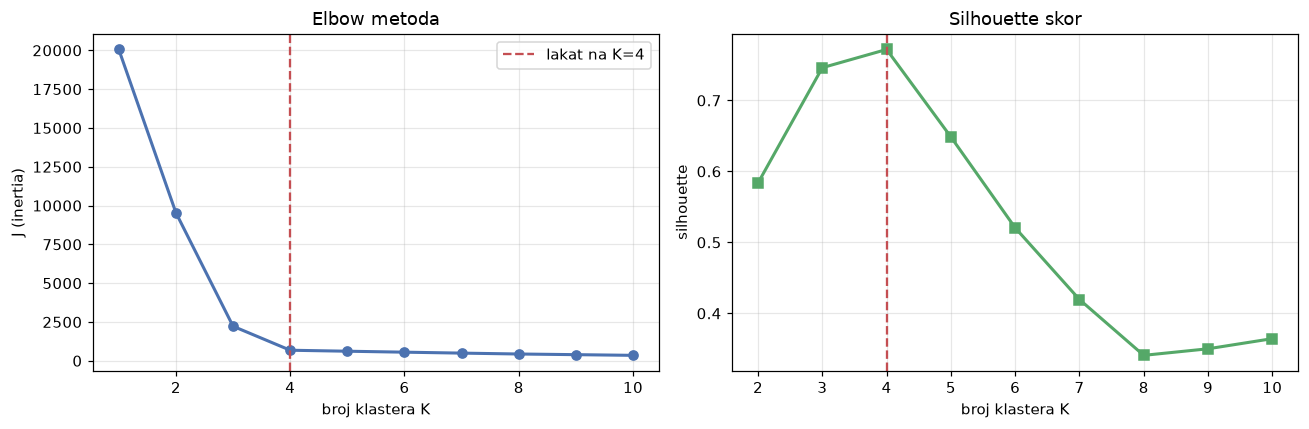

Najbolji silhouette: K = 4


In [6]:
opseg = range(1, 11)
J_lista, sil = [], []
for k in opseg:
    km = KMeans(n_clusters=k, n_init=20, random_state=RS).fit(X)
    J_lista.append(km.inertia_)
    sil.append(silhouette_score(X, km.labels_) if k > 1 else np.nan)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(list(opseg), J_lista, "o-", lw=2, color="#4C72B0")
ax[0].axvline(4, color="#C44E52", ls="--", label="lakat na K=4")
ax[0].set_xlabel("broj klastera K"); ax[0].set_ylabel("J (inertia)")
ax[0].set_title("Elbow metoda"); ax[0].legend()

ax[1].plot(list(opseg), sil, "s-", lw=2, color="#55A868")
ax[1].axvline(4, color="#C44E52", ls="--")
ax[1].set_xlabel("broj klastera K"); ax[1].set_ylabel("silhouette")
ax[1].set_title("Silhouette skor")
plt.tight_layout(); plt.show()
print(f"Najbolji silhouette: K = {list(opseg)[int(np.nanargmax(sil))]}")

### Primer: veličine majica

k-means se ne koristi samo kada postoje jasno razdvojeni klasteri, već i kada podaci čine
**kontinuiran skup bez očiglednih granica**. Visina i težina su pozitivno korelisane i ne
postoje prirodno odvojene grupe — ali nam ipak treba podela na S, M i L.

**Centroid klastera** postaje tipična visina i težina za tu veličinu.

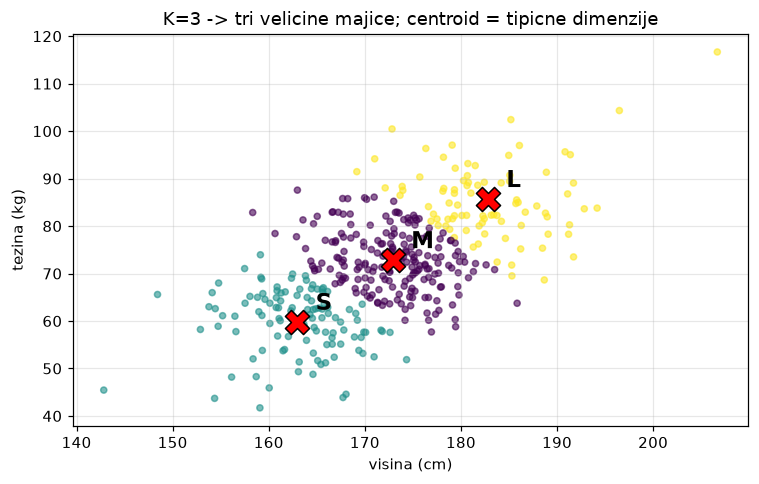

   S: visina 163.0 cm, tezina 59.8 kg, 113 ljudi
   M: visina 172.9 cm, tezina 72.8 kg, 201 ljudi
   L: visina 182.8 cm, tezina 85.6 kg, 86 ljudi


In [7]:
r = np.random.RandomState(RS)
visina = r.normal(172, 9, 400)
tezina = 0.9 * (visina - 172) + r.normal(72, 9, 400)
majice = np.c_[visina, tezina]

km_t = KMeans(n_clusters=3, n_init=20, random_state=RS).fit(StandardScaler().fit_transform(majice))
sc = StandardScaler().fit(majice)
centri = sc.inverse_transform(km_t.cluster_centers_)
poredak = np.argsort(centri[:, 0])
oznake = {poredak[0]: "S", poredak[1]: "M", poredak[2]: "L"}

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(majice[:, 0], majice[:, 1], c=km_t.labels_, s=16, cmap="viridis", alpha=0.6)
for i, (cv, ct) in enumerate(centri):
    ax.scatter(cv, ct, c="red", s=250, marker="X", edgecolor="k", zorder=5)
    ax.annotate(oznake[i], (cv, ct), fontsize=15, fontweight="bold",
                xytext=(12, 8), textcoords="offset points")
ax.set_xlabel("visina (cm)"); ax.set_ylabel("tezina (kg)")
ax.set_title("K=3 -> tri velicine majice; centroid = tipicne dimenzije")
plt.tight_layout(); plt.show()

for i in poredak:
    print(f"   {oznake[i]}: visina {centri[i,0]:.1f} cm, tezina {centri[i,1]:.1f} kg, "
          f"{(km_t.labels_==i).sum()} ljudi")

## Ograničenja k-means algoritma

1. **Pretpostavlja sferične klastere** — ne radi dobro za izdužene ili nepravilne oblike
2. **Pretpostavlja sličnu veličinu** klastera — grupe različitih gustina se loše razdvajaju
3. **Zasnovan na Euklidskom rastojanju** → rezultat zavisi od skale, **normalizacija je neophodna**
4. **Osetljiv na outliere** — jedna ekstremna tačka može značajno pomeriti centroid
5. **Zavisi od inicijalizacije** — može se zaglaviti u lokalnom optimumu

### Kada k-means nije dobar izbor

Kada su klasteri nepravilnog oblika, različite gustine, ili ima mnogo šuma i outliera.
Tada se koriste: **hijerarhijsko klasterovanje**, **DBSCAN**, **HDBSCAN**.

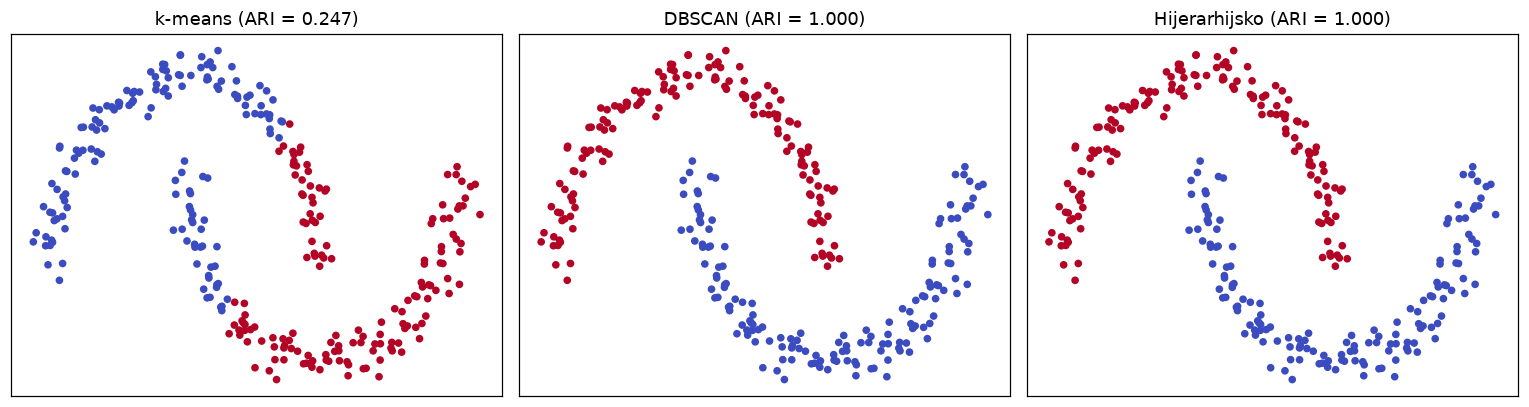

k-means secе polumesece popola jer trazi sfericne grupe.
DBSCAN i hijerarhijsko sa single linkage prate OBLIK i uspevaju.


In [8]:
Xmo, ymo = make_moons(n_samples=300, noise=0.06, random_state=RS)

fig, ax = plt.subplots(1, 3, figsize=(14, 3.8))
km = KMeans(n_clusters=2, n_init=20, random_state=RS).fit(Xmo)
ax[0].scatter(Xmo[:,0], Xmo[:,1], c=km.labels_, s=16, cmap="coolwarm")
ax[0].set_title(f"k-means (ARI = {adjusted_rand_score(ymo, km.labels_):.3f})")

db = DBSCAN(eps=0.22, min_samples=5).fit(Xmo)
ax[1].scatter(Xmo[:,0], Xmo[:,1], c=db.labels_, s=16, cmap="coolwarm")
ax[1].set_title(f"DBSCAN (ARI = {adjusted_rand_score(ymo, db.labels_):.3f})")

hi = AgglomerativeClustering(n_clusters=2, linkage="single").fit(Xmo)
ax[2].scatter(Xmo[:,0], Xmo[:,1], c=hi.labels_, s=16, cmap="coolwarm")
ax[2].set_title(f"Hijerarhijsko (ARI = {adjusted_rand_score(ymo, hi.labels_):.3f})")
for a in ax: a.set_xticks([]); a.set_yticks([])
plt.tight_layout(); plt.show()
print("k-means secе polumesece popola jer trazi sfericne grupe.")
print("DBSCAN i hijerarhijsko sa single linkage prate OBLIK i uspevaju.")

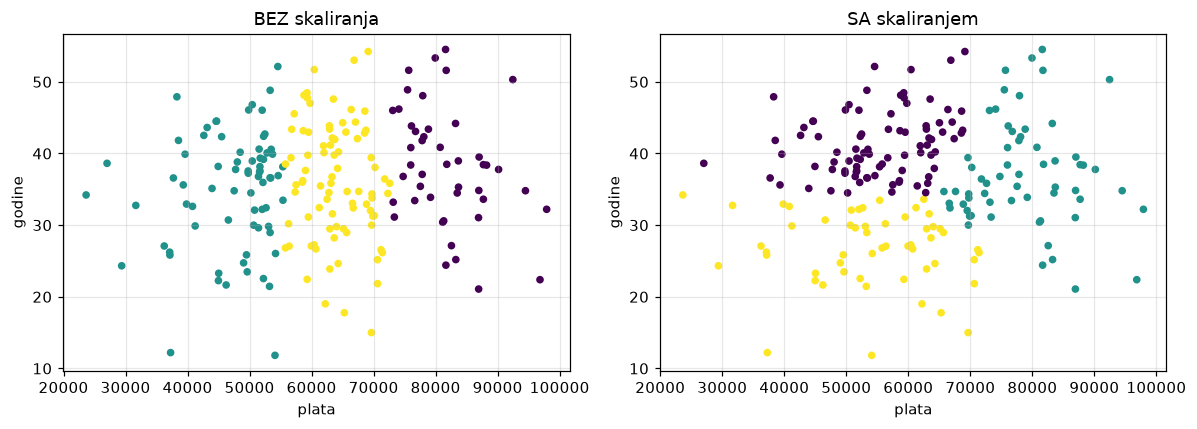

Bez skaliranja klasteri se dele SAMO po plati — godine su numericki
premale da bi uticale na Euklidsko rastojanje.


In [9]:
# osetljivost na skalu — zasto je normalizacija obavezna
plata = r.normal(60000, 15000, 200)
godine = r.normal(35, 8, 200)
Xs = np.c_[plata, godine]

km_bez = KMeans(3, n_init=20, random_state=RS).fit(Xs)
km_sa = KMeans(3, n_init=20, random_state=RS).fit(StandardScaler().fit_transform(Xs))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for a, (lab, t) in zip(ax, [(km_bez.labels_, "BEZ skaliranja"), (km_sa.labels_, "SA skaliranjem")]):
    a.scatter(Xs[:, 0], Xs[:, 1], c=lab, s=16, cmap="viridis")
    a.set_xlabel("plata"); a.set_ylabel("godine"); a.set_title(t)
plt.tight_layout(); plt.show()
print("Bez skaliranja klasteri se dele SAMO po plati — godine su numericki")
print("premale da bi uticale na Euklidsko rastojanje.")